<a href="https://colab.research.google.com/github/suhyunkim-maker/kim0901/blob/main/%EC%A3%BC%EC%8B%9D_%ED%8F%89%EA%B7%A0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_5482/4063182704.py:27: FutureWarning: YF.download() has changed argument auto_adjust default to True
  self.df = yf.download(self.ticker, start=start_date, end=end_date)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed

[000660.KS] 데이터 다운로드 중... (2025-11-05 ~ 2026-06-05)


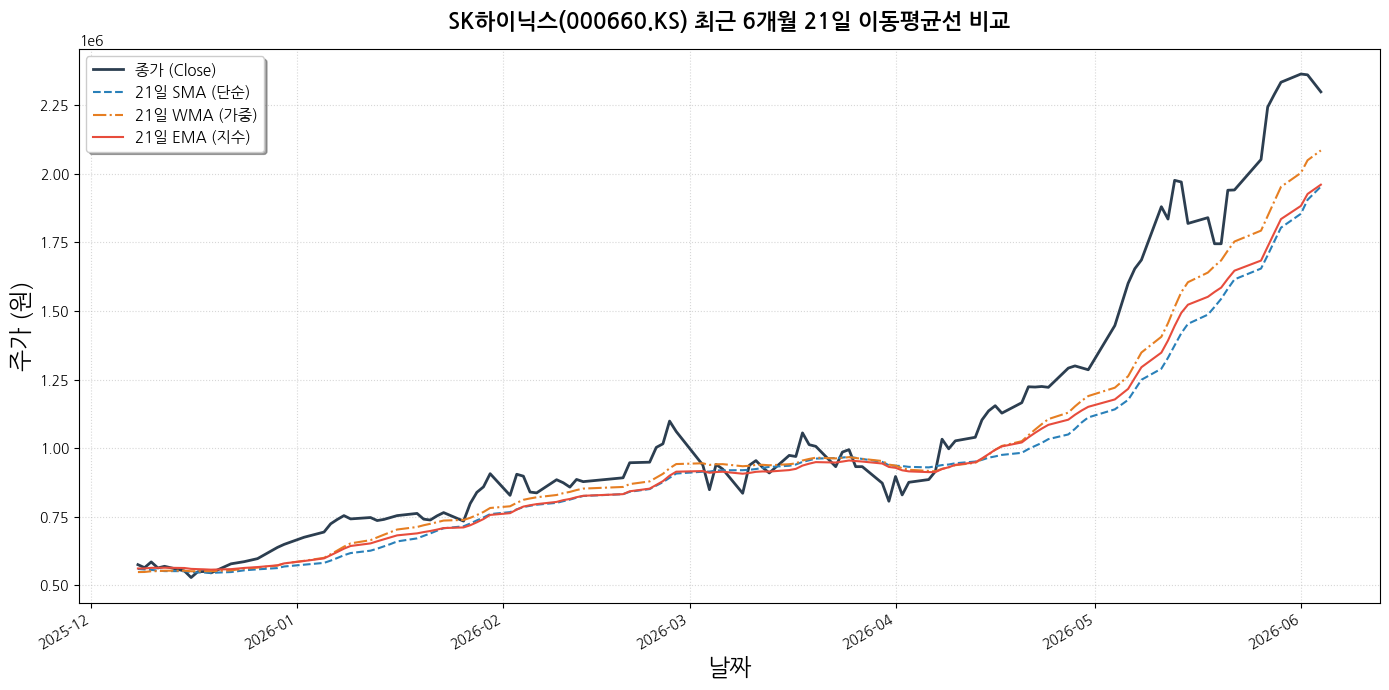

In [33]:
!pip install pandas_ta
import datetime
import matplotlib.pyplot as plt
import pandas as pd
import pandas_ta as ta
import yfinance as yf

# 한글 깨짐 방지 설정
plt.rcParams["font.family"] = "NanumGothic"  # Use NanumGothic for Korean
plt.rcParams["axes.unicode_minus"] = False


class StockAnalyzer:
    """주가 데이터 수집 및 이동평균선 분석을 위한 모듈 클래스"""

    def __init__(self, ticker):
        self.ticker = ticker
        self.df = None

    def fetch_data(self, months=6):
        """지정한 개월 수만큼의 데이터를 야후 파이낸스에서 가져옴 (앞뒤 여유 기간 포함)"""
        end_date = datetime.datetime.today()
        # 21일 이평선 계산을 위해 시작일을 1개월 더 여유있게 잡습니다.
        start_date = end_date - pd.DateOffset(months=months + 1)

        print(f"[{self.ticker}] 데이터 다운로드 중... ({start_date.date()} ~ {end_date.date()})")
        self.df = yf.download(self.ticker, start=start_date, end=end_date)
        return self.df

    def add_moving_averages(self, period=21):
        """21일 기준 SMA, WMA, EMA를 계산하여 데이터프레임에 추가"""
        if self.df is None or self.df.empty:
            raise ValueError(
                "데이터가 없습니다. fetch_data()를 먼저 실행하세요."
            )

        # 2차원 MultiIndex 데이터일 경우를 위해 Squeeze 처리하여 1차원 Series로 변환
        close_prices = self.df["Close"].squeeze()

        self.df["SMA_21"] = ta.sma(close_prices, length=period)
        self.df["WMA_21"] = ta.wma(close_prices, length=period)
        self.df["EMA_21"] = ta.ema(close_prices, length=period)
        return self.df

    def plot_chart(self, months=6):
        """최근 n개월 동안의 주가와 이동평균선을 시각화"""
        if self.df is None or "SMA_21" not in self.df.columns:
            raise ValueError("이동평균선 계산이 완료되지 않았습니다.")

        # 시각화할 타겟 기간(6개월)만 필터링
        cutoff_date = datetime.datetime.today() - pd.DateOffset(months=months)
        plot_df = self.df.loc[cutoff_date:]

        plt.figure(figsize=(14, 7))

        # 그래프 플로팅
        plt.plot(
            plot_df.index,
            plot_df["Close"],
            label="종가 (Close)",
            color="#2c3e50",
            linewidth=2,
        )
        plt.plot(
            plot_df.index,
            plot_df["SMA_21"],
            label="21일 SMA (단순)",
            color="#2980b9",
            linestyle="--",
        )
        plt.plot(
            plot_df.index,
            plot_df["WMA_21"],
            label="21일 WMA (가중)",
            color="#e67e22",
            linestyle="-."
        )
        plt.plot(
            plot_df.index,
            plot_df["EMA_21"],
            label="21일 EMA (지수)",
            color="#e74c3c",
            linestyle="-",
        )

        # 차트 스타일링
        plt.title(
            f"SK하이닉스({self.ticker}) 최근 {months}개월 21일 이동평균선 비교",
            fontsize=16,
            fontweight="bold",
            pad=15,
        )
        plt.xlabel("날짜", fontsize=17)
        plt.ylabel("주가 (원)", fontsize=17)
        plt.grid(True, linestyle=":", alpha=0.5)
        plt.legend(loc="upper left", fontsize=11, frameon=True, shadow=True)

        # x축 날짜 가독성 개선
        plt.gcf().autofmt_xdate()
        plt.tight_layout()

        plt.show()


# --- 모듈 테스트 및 실행 ---
if __name__ == "__main__":
    # SK하이닉스 티커 설정
    hynix_ticker = "000660.KS"

    # 객체 생성 및 실행
    analyzer = StockAnalyzer(hynix_ticker)
    analyzer.fetch_data(months=6)
    analyzer.add_moving_averages(period=21)
    analyzer.plot_chart(months=6)

In [5]:
import numpy as np

times = [42, 45, 47, 48, 50, 51, 55, 180]

arithmetic_mean = np.mean(times)
print(f"전체 데이터의 산술 평균: {arithmetic_mean}")

전체 데이터의 산술 평균: 64.75


In [7]:
import numpy as np

times = [42, 45, 47, 48, 50, 51, 55, 180]

# 180을 제외한 데이터
times_filtered = [t for t in times if t != 180]

# 중앙값 계산
median_filtered = np.median(times_filtered)
print(f"180을 제외한 데이터의 중앙값: {median_filtered}")

180을 제외한 데이터의 중앙값: 48.0


In [9]:
import numpy as np

# 180을 제외한 데이터의 산술평균 계산
arithmetic_mean_filtered = np.mean(times_filtered)
print(f"180을 제외한 데이터의 산술 평균: {arithmetic_mean_filtered}")

180을 제외한 데이터의 산술 평균: 48.285714285714285


계산 및 설명
전체 데이터 산술 평균	64.75
(전체 합계 518) ÷ (학생 8명) = 64.75


전체 학생의 평균 과제 수행 시간은 약 64분 45초입니다.

분석 항목결과값 (단위: 분)계산 및 설명'180' 제외 산술 평균약 48.3(제외 후 합계 338) ÷ (학생 7명) = 48.28...가장 오래 걸린 학생을 제외한 나머지 7명 학생의 평균 시간입니다.(참고) 이전 전체 평균64.75180이 포함되었을 때의 평균으로, 제외 후 평균과 무려 약 16.5분의 큰 차이가 납니다.

In [27]:
import matplotlib.font_manager as fm

# List all available fonts
font_list = fm.findSystemFonts(fontpaths=None, fontext='ttf')
print("Total fonts found:", len(font_list))

nanum_fonts = [f for f in font_list if 'Nanum' in f or 'nanum' in f]
print("Nanum fonts found:", len(nanum_fonts))
for f in nanum_fonts:
    print(f)

Total fonts found: 29
Nanum fonts found: 12
/usr/share/fonts/truetype/nanum/NanumSquareRoundR.ttf
/usr/share/fonts/truetype/nanum/NanumBarunGothicBold.ttf
/usr/share/fonts/truetype/nanum/NanumSquareB.ttf
/usr/share/fonts/truetype/nanum/NanumSquareRoundB.ttf
/usr/share/fonts/truetype/nanum/NanumSquareR.ttf
/usr/share/fonts/truetype/nanum/NanumGothic.ttf
/usr/share/fonts/truetype/nanum/NanumMyeongjo.ttf
/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf
/usr/share/fonts/truetype/nanum/NanumGothicCodingBold.ttf
/usr/share/fonts/truetype/nanum/NanumMyeongjoBold.ttf
/usr/share/fonts/truetype/nanum/NanumGothicCoding.ttf
/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf


In [25]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# Clear matplotlib's font cache
!rm -rf ~/.cache/matplotlib

# Add the font directory to Matplotlib's font manager
font_dir = '/usr/share/fonts/truetype/nanum'
for font_file in fm.findSystemFonts(fontpaths=[font_dir]):
    fm.fontManager.addfont(font_file)

# Rebuild the font cache
fm._load_fontmanager(try_read_cache=False)

# Configure matplotlib to use NanumGothic
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False # Prevent broken minus sign

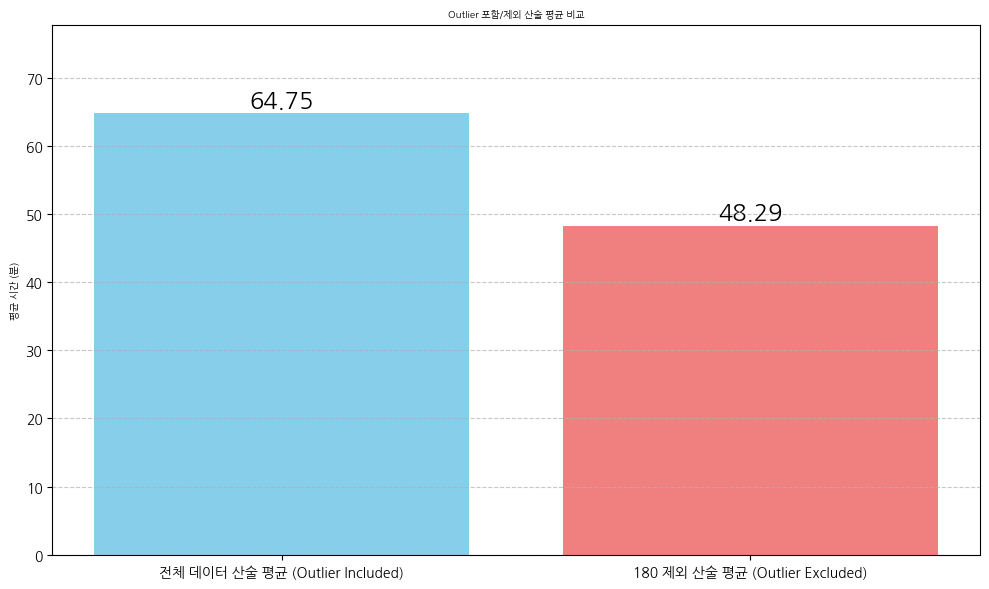

In [32]:
import matplotlib.pyplot as plt
import pandas as pd

# Create a DataFrame for plotting
mean_data = {
    'Mean Type': ['전체 데이터 산술 평균 (Outlier Included)', '180 제외 산술 평균 (Outlier Excluded)'],
    'Value': [arithmetic_mean, arithmetic_mean_filtered]
}
mean_df = pd.DataFrame(mean_data)

# Plotting the bar chart
plt.figure(figsize=(10, 6))
plt.bar(mean_df['Mean Type'], mean_df['Value'], color=['skyblue', 'lightcoral'])
plt.title('Outlier 포함/제외 산술 평균 비교', fontsize=7)
plt.ylabel('평균 시간 (분)', fontsize=7)
plt.ylim(0, max(arithmetic_mean, arithmetic_mean_filtered) * 1.2) # Set y-axis limit

for index, row in mean_df.iterrows():
    plt.text(row['Mean Type'], row['Value'] + 1, round(row['Value'], 2), color='black', ha='center', fontsize=17)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [21]:
# Install Korean font (NanumGothic)
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

Please **restart the runtime** (Runtime -> Restart runtime...) after executing the above cells for the font changes to take effect. Then, re-run the plotting code.

```python
import numpy as np
import matplotlib.pyplot as plt

data = [42, 45, 47, 48, 50, 51, 55, 180]
mean_val = np.mean(data)
median_val = np.median(data)

plt.figure(figsize=(10, 3.5))

# Plot all points
plt.scatter(data, [1]*len(data), color='skyblue', s=150, zorder=3, edgecolor='black', label='Majority Students')
# Highlight outlier
plt.scatter([180], [1], color='salmon', s=150, zorder=3, edgecolor='black', label='Outlier (180)')

# Add vertical lines for mean and median
plt.axvline(x=mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean ({mean_val:.1f})')
plt.axvline(x=median_val, color='green', linestyle='-', linewidth=2, label=f'Median ({median_val:.1f})')

plt.title('Misleading Arithmetic Mean vs Actual Distribution')
plt.xlabel('Task Completion Time (minutes)')
plt.yticks([]) # Hide y-axis as it's just a 1D number line
plt.legend(loc='upper right')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Annotate the gap
plt.annotate('Empty space\n(No students here)', xy=(100, 1), xytext=(100, 1.2),
             arrowprops=dict(facecolor='gray', shrink=0.05),
             ha='center', va='bottom', color='dimgray')

plt.tight_layout()
plt.savefig('mean_misleading.png')


```

결론부터 말씀드리면, 이 사례에서는 산술평균만 보고 학생들의 일반적인 과제 수행 시간을 판단해서는 **절대 안 됩니다.** 그 이유를 체계적으로 분석해 드리겠습니다.

---

### 1. 📊 데이터 요약

* **전체 학생 수:** 8명
* **산술평균:** 약 64.8분
* **실제 데이터 분포:** 8명 중 **7명(약 88%)이 40~50분대**에 과제를 마쳤으며, 단 1명만 180분이 걸렸습니다.

### 2. 🔍 주요 발견사항

산술평균이 대푯값으로서 실패한 이유를 표로 정리했습니다.

| 분석 항목 | 수치 (단위: 분) | 설명 (왜 평균이 부적절한가?) |
| --- | --- | --- |
| **평균 이상 소요된 학생** | **1명 (12.5%)** | 평균 시간(64.8분)보다 오래 걸린 학생은 180분이 걸린 1명뿐입니다. |
| **평균 이하 소요된 학생** | **7명 (87.5%)** | 대다수의 학생이 평균보다 훨씬 일찍(최대 약 23분 차이) 과제를 끝냈습니다. |
| **결론적 오류** | **-** | 산술평균을 '일반적인 시간'으로 잡으면, 과제를 아주 빨리 끝낸 7명의 성과를 심각하게 과소평가하게 됩니다. |

### 3. 📈 시각화

화면 상단에 출력된 1차원 점 그래프를 확인해 주세요.

* 파란색 점들이 모여 있는 곳이 실제 학생들의 **일반적인 과제 수행 시간(40~55분)** 입니다.
* 빨간색 점선으로 표시된 **산술평균(64.8분)** 은 대다수 학생의 위치에서 오른쪽으로 한참 벗어나 있으며, 해당 시간대 주변에는 아무런 데이터(학생)도 존재하지 않는 텅 빈 공간임을 시각적으로 명확히 알 수 있습니다.
* 반면 초록색 실선인 **중앙값(49.0분)** 은 학생들이 밀집한 구간의 정중앙을 잘 관통하고 있습니다.

### 4. 💡 인사이트 및 제안

1. **평균의 착시(함정) 주의:** 산술평균은 모든 값을 더해서 나누기 때문에 '180'과 같은 극단적인 이상치(Outlier) 하나에 멱살이 잡혀 끌려가는 치명적인 약점이 있습니다. 이 데이터에서 64.8분이라는 평균은 그 누구의 체감 시간도 대변하지 못하는 '가짜 대푯값'입니다.
2. **목적에 맞는 대푯값 선택:** '일반적인' 수준을 파악하는 것이 목적이라면, 극단적인 값의 영향을 받지 않는 **중앙값(Median, 49분)** 이나 극단값을 제거한 **절사평균(약 48.3분)** 을 지표로 삼아야 실체적 진실에 부합합니다.
3. **잘못된 의사결정 방지 (Action Item):** 만약 산술평균(64.8분)만 보고 "학생들이 과제에 1시간 이상 쩔쩔매고 있구나"라고 착각하여 다음 과제 난이도를 대폭 낮춘다면, 대다수 학생(40분대 완료)에게는 너무 쉬운 과제가 되어 교육 효과가 떨어질 것입니다. 항상 요약된 통계치(평균) 이면에 숨겨진 '데이터의 실제 분포(시각화)'를 함께 확인하는 의사결정 습관을 들여야 합니다.

Count: 8
Mean: 64.75
Median: 49.0


/tmp/ipykernel_5482/355083331.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=['Task Time'])


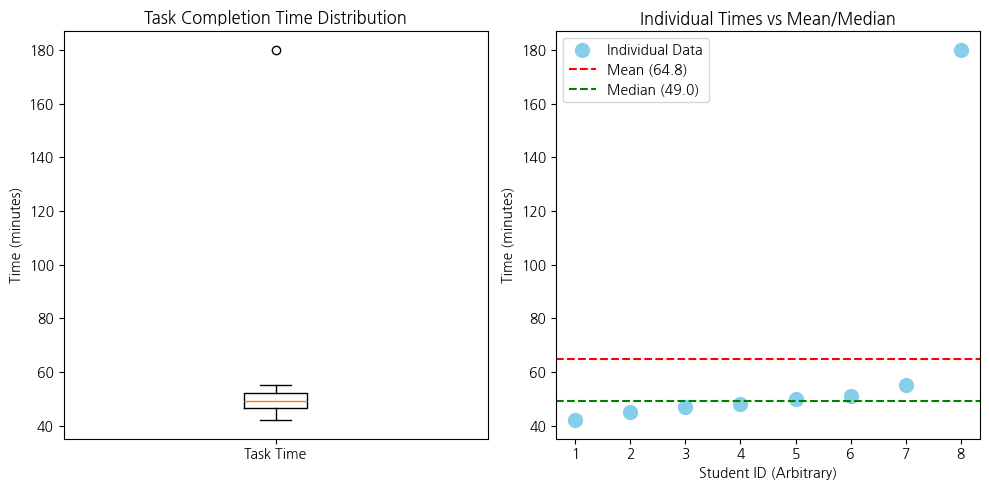

In [39]:
import numpy as np
import matplotlib.pyplot as plt

data = [42, 45, 47, 48, 50, 51, 55, 180]
mean_val = np.mean(data)
median_val = np.median(data)

print(f"Count: {len(data)}")
print(f"Mean: {mean_val}")
print(f"Median: {median_val}")

plt.figure(figsize=(10, 5))

# Boxplot
plt.subplot(1, 2, 1)
plt.boxplot(data, labels=['Task Time'])
plt.title('Task Completion Time Distribution')
plt.ylabel('Time (minutes)')

# Scatter plot with Mean line
plt.subplot(1, 2, 2)
plt.scatter(range(1, len(data) + 1), data, color='skyblue', s=100, label='Individual Data')
plt.axhline(y=mean_val, color='r', linestyle='--', label=f'Mean ({mean_val:.1f})')
plt.axhline(y=median_val, color='g', linestyle='--', label=f'Median ({median_val:.1f})')
plt.title('Individual Times vs Mean/Median')
plt.xlabel('Student ID (Arbitrary)')
plt.ylabel('Time (minutes)')
plt.legend()

plt.tight_layout()
plt.savefig('task_time_analysis.png')

Count Filtered: 7
Sum Filtered: 338
Mean Filtered: 48.29
Mean All: 64.75


/tmp/ipykernel_5482/2289659619.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_all, data_filtered], labels=['With Outlier (180)', 'Without Outlier'])


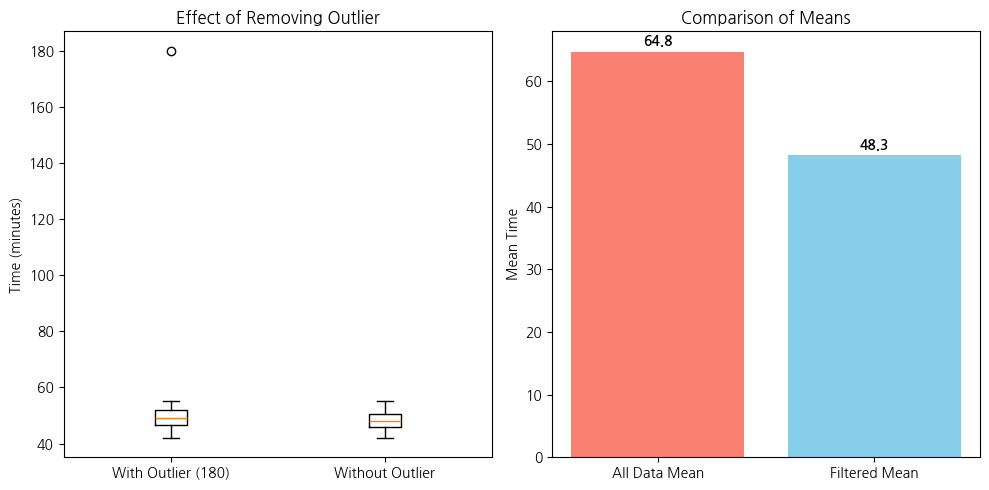

In [38]:
import numpy as np
import matplotlib.pyplot as plt

data_all = [42, 45, 47, 48, 50, 51, 55, 180]
data_filtered = [x for x in data_all if x != 180]

mean_all = np.mean(data_all)
mean_filtered = np.mean(data_filtered)

print(f"Count Filtered: {len(data_filtered)}")
print(f"Sum Filtered: {sum(data_filtered)}")
print(f"Mean Filtered: {mean_filtered:.2f}")
print(f"Mean All: {mean_all:.2f}")

plt.figure(figsize=(10, 5))

# Boxplot
plt.subplot(1, 2, 1)
plt.boxplot([data_all, data_filtered], labels=['With Outlier (180)', 'Without Outlier'])
plt.title('Effect of Removing Outlier')
plt.ylabel('Time (minutes)')

# Bar chart
plt.subplot(1, 2, 2)
means = [mean_all, mean_filtered]
bars = plt.bar(['All Data Mean', 'Filtered Mean'], means, color=['salmon', 'skyblue'])
plt.title('Comparison of Means')
plt.ylabel('Mean Time')
for i, v in enumerate(means):
    plt.text(i, v + 1, f"{v:.1f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('filtered_time_analysis.png')

Mean All: 64.75
Mean Filtered: 48.29
Difference: 16.46


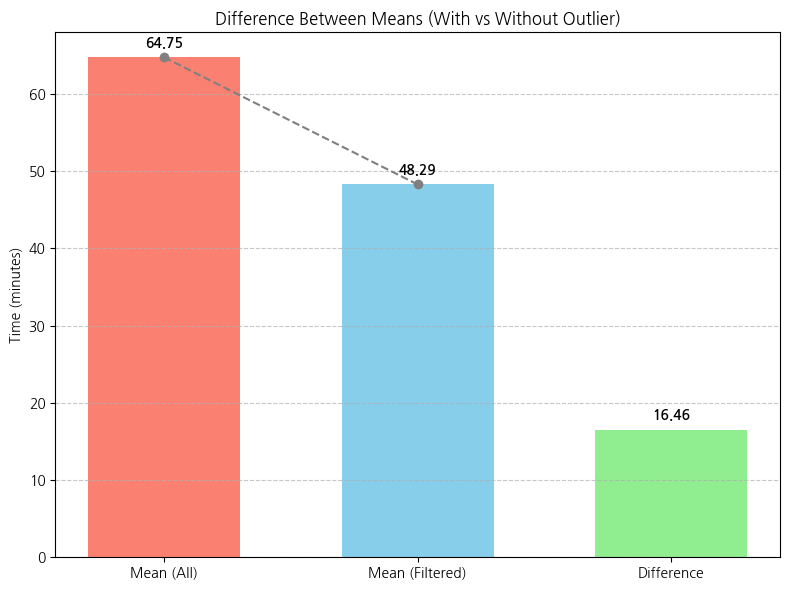

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# Data
mean_all = 518 / 8  # 64.75
mean_filtered = 338 / 7  # 48.2857...
diff = mean_all - mean_filtered

print(f"Mean All: {mean_all:.2f}")
print(f"Mean Filtered: {mean_filtered:.2f}")
print(f"Difference: {diff:.2f}")

plt.figure(figsize=(8, 6))

# Bar chart to show the difference
labels = ['Mean (All)', 'Mean (Filtered)', 'Difference']
values = [mean_all, mean_filtered, diff]
colors = ['salmon', 'skyblue', 'lightgreen']

bars = plt.bar(labels, values, color=colors, width=0.6)

# Add text labels on top of the bars
for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{value:.2f}", ha='center', va='bottom', fontweight='bold')

# Draw a line showing the drop
plt.plot([0, 1], [mean_all, mean_filtered], color='gray', linestyle='dashed', marker='o')

plt.title('Difference Between Means (With vs Without Outlier)')
plt.ylabel('Time (minutes)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('mean_difference.png')

/tmp/ipykernel_5482/2527306583.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


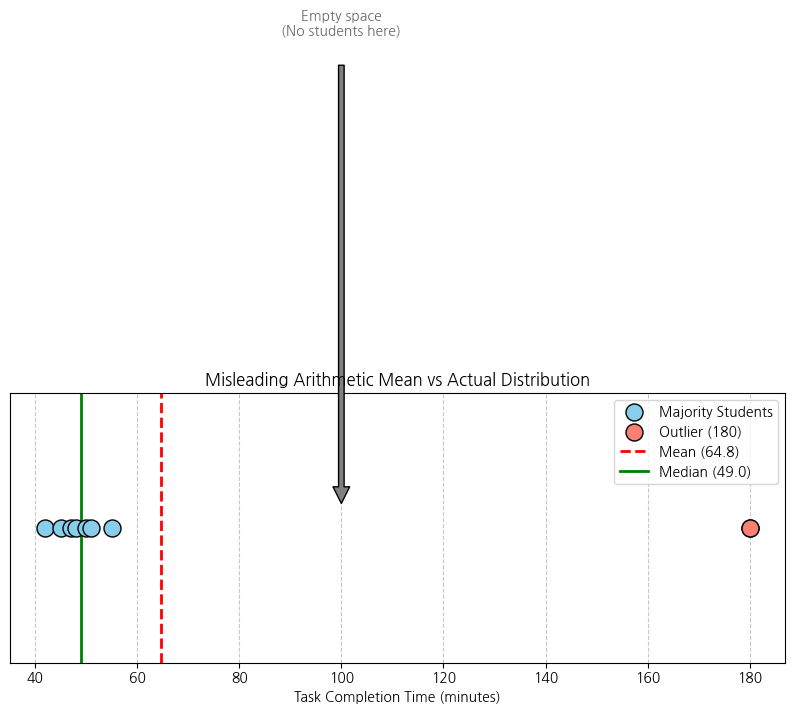

In [36]:
import numpy as np
import matplotlib.pyplot as plt

data = [42, 45, 47, 48, 50, 51, 55, 180]
mean_val = np.mean(data)
median_val = np.median(data)

plt.figure(figsize=(10, 3.5))

# Plot all points
plt.scatter(data, [1]*len(data), color='skyblue', s=150, zorder=3, edgecolor='black', label='Majority Students')
# Highlight outlier
plt.scatter([180], [1], color='salmon', s=150, zorder=3, edgecolor='black', label='Outlier (180)')

# Add vertical lines for mean and median
plt.axvline(x=mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean ({mean_val:.1f})')
plt.axvline(x=median_val, color='green', linestyle='-', linewidth=2, label=f'Median ({median_val:.1f})')

plt.title('Misleading Arithmetic Mean vs Actual Distribution')
plt.xlabel('Task Completion Time (minutes)')
plt.yticks([]) # Hide y-axis as it's just a 1D number line
plt.legend(loc='upper right')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Annotate the gap
plt.annotate('Empty space\n(No students here)', xy=(100, 1), xytext=(100, 1.2),
             arrowprops=dict(facecolor='gray', shrink=0.05),
             ha='center', va='bottom', color='dimgray')

plt.tight_layout()
plt.savefig('mean_misleading.png')


In [ ]:
df=yf.download
